# Statistical arbitrage with Cointegration

## Pairs Trading & Statistical Arbitrage

Statistical arbitrage refers to strategies that employ some statistical model or method to take
advantage of what appears to be relative mispricing of assets, while maintaining a level of
market neutrality.

Pairs trading is a conceptually straightforward strategy that has been employed by algorithmic traders since at least the mid-eighties ([Gatev, Goetzmann, and Rouwenhorst 2006](http://www-stat.wharton.upenn.edu/~steele/Courses/434/434Context/PairsTrading/PairsTradingGGR.pdf)). The goal is to find two assets whose prices have historically moved together, track the spread (the difference between their prices), and, once the spread widens, buy the
loser that has dropped below the common trend and short the winner. If the relationship persists, the long and/or the short leg will deliver profits as prices converge and the positions are closed.

This approach extends to a multivariate context by forming baskets from multiple securities and trading one asset against a basket of two baskets against each other.

## Pairs Trading in Practice

In practice, the strategy requires two steps:

1. **Formation phase**: Identify securities that have a long-term mean-reverting relationship. Ideally, the spread should have a high variance to allow for frequent profitable trades while reliably reverting to the common trend.
2. **Trading phase**: Trigger entry and exit trading rules as price movements cause thespread to diverge and converge.

Several approaches to the formation and trading phases have emerged from increasingly active research in this area, across multiple asset classes, over the last several years. The book outlines the key differences between them; the notebook dives into an example application.

## Imports & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from collections import Counter

from time import time
from pathlib import Path

import numpy as np
import pandas as pd

from pykalman import KalmanFilter
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.api import VAR

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
idx = pd.IndexSlice
sns.set_style('whitegrid')

In [4]:
def format_time(t):
    m_, s = divmod(t, 60)
    h, m = divmod(m_, 60)
    return f'{h:>02.0f}:{m:>02.0f}:{s:>02.0f}'

### Johansen Test Critical Values

In [5]:
critical_values = {0: {.9: 13.4294, .95: 15.4943, .99: 19.9349},
                   1: {.9: 2.7055, .95: 3.8415, .99: 6.6349}}

In [6]:
trace0_cv = critical_values[0][.95] # critical value for at most 0 cointegration relationships
trace1_cv = critical_values[1][.95] # critical value for at most 1 cointegration relationship

## Load Data

In [16]:
DATA_PATH = Path('..', 'data') 
STORE = DATA_PATH / 'assets.h5'

### Get backtest prices

Combine OHLCV prices for relevant stock and ETF tickers.

In [66]:
def get_backtest_prices():
    with pd.HDFStore('data/data.h5') as store:
        tickers = store['tickers']
    print(tickers)

    with pd.HDFStore(STORE) as store:
        prices = (pd.concat([
            store['stooq/us/nyse/stocks/prices'],
            store['stooq/us/nyse/etfs/prices'],
            store['stooq/us/nasdaq/etfs/prices'],
            store['stooq/us/nasdaq/stocks/prices']])
                  .sort_index()
                  .loc[idx[tickers.index, '2016':'2019'], :])
    prices.to_hdf('backtest.h5', 'prices')
    tickers.to_hdf('backtest.h5', 'tickers')

In [67]:
get_backtest_prices()

AA.US                        ALCOA CORP
ABT.US              ABBOTT LABORATORIES
AIG.US               AMERICAN INT GROUP
AMT.US              AMERICAN TOWER CORP
AXP.US              AMERICAN EXPRESS CO
                       ...             
VOD.US               VODAFONE GROUP PLC
VRTX.US      VERTEX PHARMACEUTICALS INC
WBA.US     WALGREENS BOOTS ALLIANCE INC
WDC.US             WESTERN DIGITAL CORP
WYNN.US                WYNN RESORTS LTD
Length: 304, dtype: object


### Load Stock Prices

In [24]:
# see notebook 05_cointagration_tests
stocks = pd.read_hdf('data/data.h5', 'stocks/close').loc['2015':]
stocks.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2015-01-02 to 2019-12-31
Columns: 172 entries, AAPL.US to AEP.US
dtypes: float64(172)
memory usage: 1.7 MB


### Load ETF Data

In [26]:
# see notebook 05_cointagration_tests
etfs = pd.read_hdf('data/data.h5', 'etfs/close').loc['2015':]
etfs.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2015-01-02 to 2019-12-31
Columns: 132 entries, SPY.US to VNM.US
dtypes: float64(132)
memory usage: 1.3 MB


### Load Ticker Dictionary

In [34]:
with pd.HDFStore('data/data.h5') as store:
    tickers = store['tickers']
    print(tickers)

Series([], dtype: object)


In [35]:
names = pd.read_hdf('data/data.h5', 'tickers').to_dict()

In [36]:
pd.Series(names).count()

0

## Precompute Cointegration

In [38]:
etfs.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2019-12-17', '2019-12-18', '2019-12-19', '2019-12-20',
               '2019-12-23', '2019-12-24', '2019-12-26', '2019-12-27',
               '2019-12-30', '2019-12-31'],
              dtype='datetime64[ns]', name='date', length=1258, freq=None)

In [40]:
stocks.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2019-12-17', '2019-12-18', '2019-12-19', '2019-12-20',
               '2019-12-23', '2019-12-24', '2019-12-26', '2019-12-27',
               '2019-12-30', '2019-12-31'],
              dtype='datetime64[ns]', name='date', length=1258, freq=None)

In [ ]:
def test_cointegration(etfs, stocks, test_end, lookback=2):
    start = time()
    results = []
    test_start = test_end - pd.DateOffset(years=lookback) + pd.DateOffset(days=1)
    etf_tickers = etfs.columns.tolist()
    etf_data = etfs.loc[str(test_start):str(test_end)]

    stock_tickers = stocks.columns.tolist()
    stock_data = stocks.loc[str(test_start):str(test_end)]
    n = len(etf_tickers) * len(stock_tickers)
    j = 0
    for i, s1 in enumerate(etf_tickers, 1):
        for s2 in stock_tickers:
            j += 1
            if j % 1000 == 0:
                print(f'\t{j:5,.0f} ({j/n:3.1%}) | {time() - start:.2f}')
            df = etf_data.loc[:, [s1]].dropna().join(stock_data.loc[:, [s2]].dropna(), how='inner') # merge on dates, so each row is a date with price on etf and stock
            print(df.columns)
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                var = VAR(df)
                lags = var.select_order()
                result = [test_end, s1, s2]
                order = lags.selected_orders['aic']
                result += [coint(df[s1], df[s2], trend='c')[1], coint(df[s2], df[s1], trend='c')[1]] # first argument is dependent variable, second is independent variable

            cj = coint_johansen(df, det_order=0, k_ar_diff=order)
            result += (list(cj.lr1) + list(cj.lr2) + list(cj.evec[:, cj.ind[0]]))
            results.append(result)
    return results

### Define Test Periods

In [46]:
dates = stocks.loc['2016-12':'2019-6'].resample('Q').last().index # get quarter end
dates

DatetimeIndex(['2016-12-31', '2017-03-31', '2017-06-30', '2017-09-30',
               '2017-12-31', '2018-03-31', '2018-06-30', '2018-09-30',
               '2018-12-31', '2019-03-31', '2019-06-30'],
              dtype='datetime64[ns]', name='date', freq='Q-DEC')

### Run Tests

In [12]:
test_results = []
columns = ['test_end', 's1', 's2', 'eg1', 'eg2',
           'trace0', 'trace1', 'eig0', 'eig1', 'w1', 'w2']

for test_end in dates:
    print(test_end)
    result = test_cointegration(etfs, stocks, test_end=test_end)
    test_results.append(pd.DataFrame(result, columns=columns))

pd.concat(test_results).to_hdf('backtest.h5', 'cointegration_test')

NameError: name 'dates' is not defined

#### Reload  Test Results

In [17]:
test_results = pd.read_hdf('backtest.h5', 'cointegration_test')
test_results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 249744 entries, 0 to 22703
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   test_end  249744 non-null  datetime64[ns]
 1   s1        249744 non-null  object        
 2   s2        249744 non-null  object        
 3   eg1       249744 non-null  float64       
 4   eg2       249744 non-null  float64       
 5   trace0    249744 non-null  float64       
 6   trace1    249744 non-null  float64       
 7   eig0      249744 non-null  float64       
 8   eig1      249744 non-null  float64       
 9   w1        249744 non-null  float64       
 10  w2        249744 non-null  float64       
dtypes: datetime64[ns](1), float64(8), object(2)
memory usage: 22.9+ MB


## Identify Cointegrated Pairs

### Significant Johansen Trace Statistic

In [18]:
test_results['joh_sig'] = ((test_results.trace0 > trace0_cv) &
                           (test_results.trace1 <= trace1_cv))

In [19]:
test_results.joh_sig.value_counts(normalize=True)

joh_sig
False    0.931822
True     0.068178
Name: proportion, dtype: float64

### Significant Engle Granger Test

In [20]:
# remember that engle granger test first fit s1 on s2, then s2 on s1, getting the residuals, then testing if the residuals are stationary using ADF test. the null hypothesis is that residual contains a unit root 
test_results['eg'] = test_results[['eg1', 'eg2']].min(axis=1) # get the most significant Engle-Granger p-value, meaning the strongest evidence for cointegration
test_results['s1_dep'] = test_results.eg1 < test_results.eg2 
test_results['eg_sig'] = (test_results.eg < .05)

In [21]:
test_results.eg_sig.value_counts(normalize=True)

eg_sig
False    0.91255
True     0.08745
Name: proportion, dtype: float64

### Comparison Engle-Granger vs Johansen

In [22]:
test_results['coint'] = (test_results.eg_sig & test_results.joh_sig)
test_results.coint.value_counts(normalize=True)

coint
False    0.962089
True     0.037911
Name: proportion, dtype: float64

In [23]:
test_results = test_results.drop(['eg1', 'eg2', 'trace0', 'trace1', 'eig0', 'eig1'], axis=1)
test_results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 249744 entries, 0 to 22703
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   test_end  249744 non-null  datetime64[ns]
 1   s1        249744 non-null  object        
 2   s2        249744 non-null  object        
 3   w1        249744 non-null  float64       
 4   w2        249744 non-null  float64       
 5   joh_sig   249744 non-null  bool          
 6   eg        249744 non-null  float64       
 7   s1_dep    249744 non-null  bool          
 8   eg_sig    249744 non-null  bool          
 9   coint     249744 non-null  bool          
dtypes: bool(4), datetime64[ns](1), float64(3), object(2)
memory usage: 14.3+ MB


### Comparison

In [24]:
test_results

,test_end,s1,s2,w1,w2,joh_sig,eg,s1_dep,eg_sig,coint
0,2016-12-31,SPY.US,AAPL.US,0.060598,0.336213,False,0.660334,False,False,False
1,2016-12-31,SPY.US,AMZN.US,0.142613,-0.151897,False,0.476889,True,False,False
2,2016-12-31,SPY.US,MSFT.US,0.163787,-0.136412,False,0.513778,True,False,False
3,2016-12-31,SPY.US,BAC.US,0.136688,-0.057910,False,0.477606,True,False,False
4,2016-12-31,SPY.US,GOOGL.US,0.082204,0.102017,False,0.700180,False,False,False
...,...,...,...,...,...,...,...,...,...,...
22699,2019-06-30,VNM.US,FSLR.US,1.226689,-0.176223,False,0.010013,True,True,False
22700,2019-06-30,VNM.US,ADI.US,0.624485,0.032279,False,0.762450,True,False,False
22701,2019-06-30,VNM.US,PCG.US,0.727903,-0.001373,False,0.691749,True,False,False
22702,2019-06-30,VNM.US,NVS.US,0.512736,0.167578,False,0.600209,True,False,False


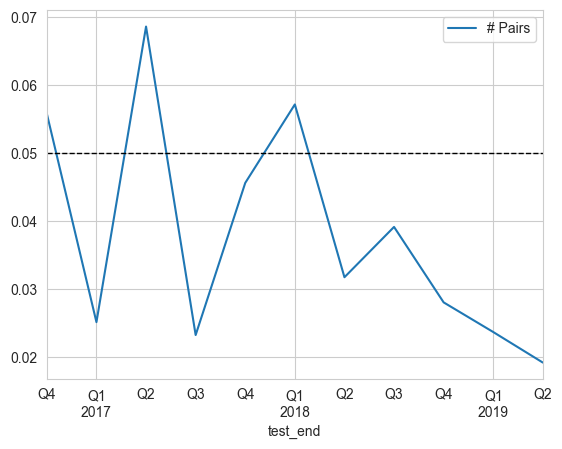

In [25]:
ax = test_results.groupby('test_end').coint.mean().to_frame('# Pairs').plot() # plot the proportion of cointegrated pairs over time
ax.axhline(.05, lw=1, ls='--', c='k');

### Select Candidate Pairs

In [26]:
test_results

,test_end,s1,s2,w1,w2,joh_sig,eg,s1_dep,eg_sig,coint
0,2016-12-31,SPY.US,AAPL.US,0.060598,0.336213,False,0.660334,False,False,False
1,2016-12-31,SPY.US,AMZN.US,0.142613,-0.151897,False,0.476889,True,False,False
2,2016-12-31,SPY.US,MSFT.US,0.163787,-0.136412,False,0.513778,True,False,False
3,2016-12-31,SPY.US,BAC.US,0.136688,-0.057910,False,0.477606,True,False,False
4,2016-12-31,SPY.US,GOOGL.US,0.082204,0.102017,False,0.700180,False,False,False
...,...,...,...,...,...,...,...,...,...,...
22699,2019-06-30,VNM.US,FSLR.US,1.226689,-0.176223,False,0.010013,True,True,False
22700,2019-06-30,VNM.US,ADI.US,0.624485,0.032279,False,0.762450,True,False,False
22701,2019-06-30,VNM.US,PCG.US,0.727903,-0.001373,False,0.691749,True,False,False
22702,2019-06-30,VNM.US,NVS.US,0.512736,0.167578,False,0.600209,True,False,False


In [27]:
def select_candidate_pairs(data):
    candidates = data[data.joh_sig | data.eg_sig] # select pairs that are significant in either Johansen or Engle-Granger test
    candidates['y'] = candidates.apply(lambda x: x.s1 if x.s1_dep else x.s2, axis=1) # y is the dependent var, if s1 is dependent on s2, then y = s1, else y = s2
    candidates['x'] = candidates.apply(lambda x: x.s2 if x.s1_dep else x.s1, axis=1)
    return candidates.drop(['s1_dep', 's1', 's2'], axis=1)

In [28]:
candidates = select_candidate_pairs(test_results)

In [29]:
candidates.to_hdf('backtest.h5', 'candidates')

In [30]:
candidates = pd.read_hdf('backtest.h5', 'candidates')
candidates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29399 entries, 6 to 22699
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   test_end  29399 non-null  datetime64[ns]
 1   w1        29399 non-null  float64       
 2   w2        29399 non-null  float64       
 3   joh_sig   29399 non-null  bool          
 4   eg        29399 non-null  float64       
 5   eg_sig    29399 non-null  bool          
 6   coint     29399 non-null  bool          
 7   y         29399 non-null  object        
 8   x         29399 non-null  object        
dtypes: bool(3), datetime64[ns](1), float64(3), object(2)
memory usage: 1.7+ MB


#### # Candidates over Time

In [31]:
candidates

,test_end,w1,w2,joh_sig,eg,eg_sig,coint,y,x
6,2016-12-31,0.112295,0.052680,True,0.744821,False,False,SPY.US,C.US
12,2016-12-31,0.142082,-0.325900,False,0.044346,True,False,SPY.US,NVDA.US
15,2016-12-31,0.308580,-1.448434,True,0.015434,True,True,CSCO.US,SPY.US
21,2016-12-31,0.117961,0.007331,True,0.639055,False,False,SPY.US,GS.US
35,2016-12-31,0.221539,-0.529602,True,0.012558,True,True,SPY.US,AMD.US
...,...,...,...,...,...,...,...,...,...
22630,2019-06-30,0.724119,0.022012,True,0.242477,False,False,VNM.US,REGN.US
22664,2019-06-30,0.730042,0.106124,True,0.036398,True,True,EXPE.US,VNM.US
22681,2019-06-30,0.819393,-0.548634,True,0.032795,True,True,TFC.US,VNM.US
22695,2019-06-30,1.162844,-0.904759,True,0.027240,True,True,FITB.US,VNM.US


<Axes: xlabel='test_end'>

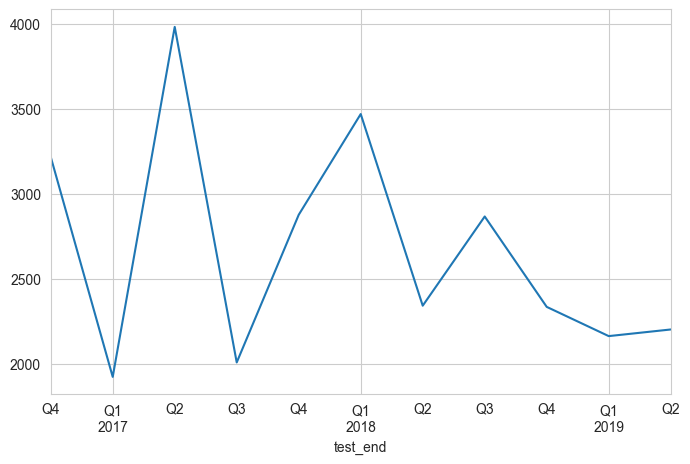

In [32]:
candidates.groupby('test_end').size().plot(figsize=(8, 5)) # plot candidates pairs over time 

#### Most Common Pairs 

In [68]:
with pd.HDFStore('data/data.h5') as store:
    print(store.info())
    tickers = store['tickers']

<class 'pandas.io.pytables.HDFStore'>
File path: data/data.h5
/etfs/close              frame        (shape->[2516,132])
/stocks/close            frame        (shape->[2516,172])
/tickers                 series       (shape->[1])       


In [69]:
with pd.HDFStore('backtest.h5') as store:
    print(store.info())

<class 'pandas.io.pytables.HDFStore'>
File path: backtest.h5
/candidates                    frame        (shape->[29399,9])  
/cointegration_test            frame        (shape->[249744,11])
/prices                        frame        (shape->[305824,5]) 
/tickers                       series       (shape->[1])        


In [70]:
counter = Counter()
for s1, s2 in zip(candidates[candidates.joh_sig & candidates.eg_sig].y, 
                  candidates[candidates.joh_sig & candidates.eg_sig].x):
    print(s1)
    print(s2)
    print("====")
    if s1 > s2:
        counter[(s2, s1)] += 1
    else: 
        counter[(s1, s2)] += 1

CSCO.US
SPY.US
====
SPY.US
AMD.US
====
SPY.US
TEVA.US
====
CTSH.US
SPY.US
====
KR.US
SPY.US
====
HUM.US
SPY.US
====
MU.US
EEM.US
====
FCX.US
EEM.US
====
NOV.US
EEM.US
====
CCL.US
EEM.US
====
OXY.US
GLD.US
====
WBA.US
GLD.US
====
DAL.US
GLD.US
====
CL.US
GLD.US
====
CI.US
GLD.US
====
KR.US
GLD.US
====
CCL.US
GLD.US
====
LULU.US
GLD.US
====
EFA.US
AAPL.US
====
EFA.US
GOOGL.US
====
EFA.US
KO.US
====
EFA.US
MCD.US
====
EFA.US
COP.US
====
SBUX.US
EFA.US
====
EFA.US
BIIB.US
====
AXP.US
EFA.US
====
EFA.US
WMB.US
====
EFA.US
TJX.US
====
EFA.US
DVN.US
====
EFA.US
WDC.US
====
EFA.US
KMB.US
====
EFA.US
MOS.US
====
EFA.US
STX.US
====
EFA.US
STZ.US
====
EFA.US
SWKS.US
====
EFA.US
GAP.US
====
HUM.US
XLF.US
====
XLF.US
TFC.US
====
XLF.US
RF.US
====
ADI.US
XLF.US
====
HPQ.US
XLE.US
====
NKE.US
XLE.US
====
WBA.US
XLE.US
====
XLE.US
BP.US
====
DIS.US
TLT.US
====
OXY.US
TLT.US
====
MDT.US
TLT.US
====
WBA.US
TLT.US
====
SPG.US
TLT.US
====
CL.US
TLT.US
====
CI.US
TLT.US
====
CCI.US
TLT.US
====
XOM.US
GDX.U

In [71]:
most_common_pairs = pd.DataFrame(counter.most_common(10))

In [72]:
most_common_pairs

,0,1
0,"(LMT.US, THD.US)",8
1,"(TIP.US, WBA.US)",7
2,"(CSX.US, HEDJ.US)",6
3,"(AGQ.US, DAL.US)",6
4,"(EPP.US, HPQ.US)",6
5,"(EWD.US, SWKS.US)",6
6,"(EPU.US, WBA.US)",6
7,"(EWA.US, HPQ.US)",6
8,"(BBY.US, TECL.US)",6
9,"(EWJ.US, STT.US)",5


In [73]:
most_common_pairs = pd.DataFrame(most_common_pairs[0].values.tolist(), columns=['s1', 's2'])
most_common_pairs

,s1,s2
0,LMT.US,THD.US
1,TIP.US,WBA.US
2,CSX.US,HEDJ.US
3,AGQ.US,DAL.US
4,EPP.US,HPQ.US
5,EWD.US,SWKS.US
6,EPU.US,WBA.US
7,EWA.US,HPQ.US
8,BBY.US,TECL.US
9,EWJ.US,STT.US


In [9]:
with pd.HDFStore('backtest.h5') as store:
    prices = store['prices'].close.unstack('ticker').ffill(limit=5)
    tickers = store['tickers'].to_dict()

In [75]:
pd.Series(counter).index

MultiIndex([('CSCO.US',  'SPY.US'),
            ( 'AMD.US',  'SPY.US'),
            ( 'SPY.US', 'TEVA.US'),
            ('CTSH.US',  'SPY.US'),
            (  'KR.US',  'SPY.US'),
            ( 'HUM.US',  'SPY.US'),
            ( 'EEM.US',   'MU.US'),
            ( 'EEM.US',  'FCX.US'),
            ( 'EEM.US',  'NOV.US'),
            ( 'CCL.US',  'EEM.US'),
            ...
            ( 'EPU.US', 'VRTX.US'),
            (   'T.US',  'WIP.US'),
            ( 'PJP.US', 'TEVA.US'),
            (  'CL.US', 'INDY.US'),
            ( 'KMB.US', 'STPZ.US'),
            ( 'BRF.US',    'M.US'),
            ('AAPL.US',  'IDX.US'),
            ('EXPE.US',  'VNM.US'),
            ( 'TFC.US',  'VNM.US'),
            ('FITB.US',  'VNM.US')],
           length=6638)

In [76]:
cnt = pd.Series(counter).reset_index()
cnt

,level_0,level_1,0
0,CSCO.US,SPY.US,1
1,AMD.US,SPY.US,2
2,SPY.US,TEVA.US,4
3,CTSH.US,SPY.US,1
4,KR.US,SPY.US,1
...,...,...,...
6633,BRF.US,M.US,1
6634,AAPL.US,IDX.US,1
6635,EXPE.US,VNM.US,1
6636,TFC.US,VNM.US,1


In [77]:
tickers

{'AA.US': 'ALCOA CORP',
 'ABT.US': 'ABBOTT LABORATORIES',
 'AIG.US': 'AMERICAN INT GROUP',
 'AMT.US': 'AMERICAN TOWER CORP',
 'AXP.US': 'AMERICAN EXPRESS CO',
 'AZO.US': 'AUTOZONE INC',
 'B.US': 'BARRICK MINING CORP',
 'BA.US': 'BOEING CO',
 'BAC.US': 'BANK OF AMERICA CORP',
 'BAX.US': 'BAXTER INTERNATIONAL INC',
 'BB.US': 'BLACKBERRY LTD',
 'BBY.US': 'BEST BUY CO INC',
 'BDX.US': 'BECTON DICKINSON & CO',
 'BHC.US': 'BAUSCH HEALTH COS INC',
 'BHP.US': 'BHP GROUP LTD',
 'BK.US': 'BANK OF NEW YORK MELLON CORP',
 'BLK.US': 'BLACKROCK INC',
 'BMY.US': 'BRISTOL-MYERS SQUIBB CO',
 'BP.US': 'BP PLC',
 'BRK-B.US': 'BERKSHIRE HATHAWAY INC',
 'BSX.US': 'BOSTON SCIENTIFIC CORP',
 'C.US': 'CITIGROUP INC',
 'CAT.US': 'CATERPILLAR INC',
 'CCI.US': 'CROWN CASTLE INC',
 'CCL.US': 'CARNIVAL CORP',
 'CF.US': 'CF INDUSTRIES HOLDINGS INC',
 'CI.US': 'CIGNA GROUP',
 'CL.US': 'COLGATE-PALMOLIVE CO',
 'CLF.US': 'CLEVELAND-CLIFFS INC',
 'CMG.US': 'CHIPOTLE MEXICAN GRILL INC',
 'CMI.US': 'CUMMINS INC',
 'COP.U

In [78]:
cnt.columns = ['s1', 's2', 'n']
cnt['name1'] = cnt.s1.map(tickers)
cnt['name2'] = cnt.s2.map(tickers)
cnt.nlargest(10, columns='n')

,s1,s2,n,name1,name2
2393,LMT.US,THD.US,8,LOCKHEED MARTIN CORP,ISHARES MSCI THAILAND ETF
313,TIP.US,WBA.US,7,ISHARES TIPS BOND ETF,WALGREENS BOOTS ALLIANCE INC
455,CSX.US,HEDJ.US,6,CSX CORP,WISDOMTREE EUROPE HEDGED EQUITY
507,AGQ.US,DAL.US,6,PROSHARES ULTRA SILVER,DELTA AIR LINES INC
575,EPP.US,HPQ.US,6,ISHARES MSCI PACIFIC EX,HP INC
1009,EWD.US,SWKS.US,6,ISHARES MSCI SWEDEN ETF,SKYWORKS SOLUTIONS INC
1167,EPU.US,WBA.US,6,ISHARES MSCI PERU AND GLOBAL EXPOSURE,WALGREENS BOOTS ALLIANCE INC
1349,EWA.US,HPQ.US,6,ISHARES MSCI AUSTRALIA ETF,HP INC
3039,BBY.US,TECL.US,6,BEST BUY CO INC,DIREXION DAILY
126,EWJ.US,STT.US,5,ISHARES MSCI JAPAN ETF,STATE STREET CORP


In [82]:
prices

ticker,AA.US,ABT.US,AIG.US,AMT.US,AXP.US,AZO.US,B.US,BA.US,BAC.US,BAX.US,...,REGN.US,SBUX.US,STX.US,SWKS.US,TXN.US,VOD.US,VRTX.US,WBA.US,WDC.US,WYNN.US
date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,21.1609,37.6879,50.2896,84.3724,60.7677,735.48,6.63167,126.01,14.2776,34.1252,...,516.55,50.8972,25.2507,69.5607,45.1641,21.1399,122.89,66.7381,39.3861,62.285
2016-01-05,20.2048,37.6779,50.4646,86.0382,59.8328,738.86,6.54604,126.52,14.2776,34.2633,...,508.98,51.2418,25.2946,65.4229,44.6930,21.1699,123.45,64.9838,39.2169,63.462
2016-01-06,18.7659,37.3618,49.7224,85.7352,58.1724,729.20,6.79432,124.51,13.9712,34.3452,...,519.48,50.7873,24.1912,61.7260,44.4012,20.9700,122.23,63.9885,38.3434,60.177
2016-01-07,18.0235,36.4680,48.5360,83.5956,57.6463,735.96,7.48742,119.28,13.4695,33.7752,...,501.96,49.5268,24.0464,59.9531,42.9731,20.7729,114.96,65.2271,37.7117,54.514
2016-01-08,17.5874,35.7031,47.8105,82.2170,57.4588,712.06,7.20490,116.58,13.2073,33.2338,...,491.68,49.4767,22.6532,59.7087,41.8593,21.3697,110.71,65.1287,36.1203,52.297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-24,21.3744,83.2216,46.5955,213.5810,119.5850,1219.31,16.23670,331.03,32.8869,81.1592,...,376.51,83.3397,53.1564,116.2880,118.6360,16.0391,220.56,51.4522,46.0492,138.280
2019-12-26,21.2453,83.2216,46.3035,215.2680,120.2490,1210.72,16.28160,327.97,33.1679,80.8140,...,374.86,82.9196,53.5402,116.4070,118.5870,16.0887,220.25,51.9369,46.4701,139.770
2019-12-27,21.3744,83.3346,46.7154,216.4230,120.0310,1202.59,16.28960,328.19,33.0077,80.5459,...,373.32,82.9725,53.2347,116.4160,118.6760,16.2623,220.97,52.0430,45.9752,138.650


In [81]:
most_common_pairs

,s1,s2
0,LMT.US,THD.US
1,TIP.US,WBA.US
2,CSX.US,HEDJ.US
3,AGQ.US,DAL.US
4,EPP.US,HPQ.US
5,EWD.US,SWKS.US
6,EPU.US,WBA.US
7,EWA.US,HPQ.US
8,BBY.US,TECL.US
9,EWJ.US,STT.US


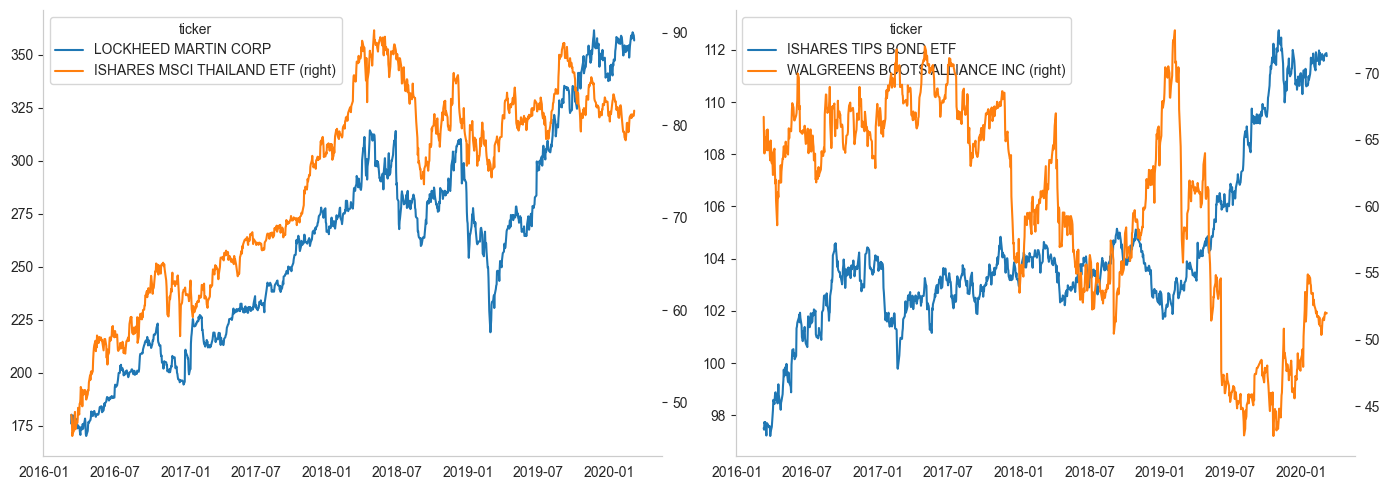

In [83]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 5))
for i in [0, 1]:
    s1, s2 = most_common_pairs.at[i, 's1'], most_common_pairs.at[i, 's2']
    prices.loc[:, [s1, s2]].rename(columns=tickers).plot(secondary_y=tickers[s2],
                                                         ax=axes[i],
                                                         rot=0)
    axes[i].grid(False)
    axes[i].set_xlabel('')

sns.despine()
fig.tight_layout() # plotting the most common cointegrated pairs

## Get Entry and Exit Dates 

### Smooth prices using Kalman filter

In [10]:
prices

ticker,AA.US,ABT.US,AIG.US,AMT.US,AXP.US,AZO.US,B.US,BA.US,BAC.US,BAX.US,...,REGN.US,SBUX.US,STX.US,SWKS.US,TXN.US,VOD.US,VRTX.US,WBA.US,WDC.US,WYNN.US
date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,21.1609,37.6879,50.2896,84.3724,60.7677,735.48,6.63167,126.01,14.2776,34.1252,...,516.55,50.8972,25.2507,69.5607,45.1641,21.1399,122.89,66.7381,39.3861,62.285
2016-01-05,20.2048,37.6779,50.4646,86.0382,59.8328,738.86,6.54604,126.52,14.2776,34.2633,...,508.98,51.2418,25.2946,65.4229,44.6930,21.1699,123.45,64.9838,39.2169,63.462
2016-01-06,18.7659,37.3618,49.7224,85.7352,58.1724,729.20,6.79432,124.51,13.9712,34.3452,...,519.48,50.7873,24.1912,61.7260,44.4012,20.9700,122.23,63.9885,38.3434,60.177
2016-01-07,18.0235,36.4680,48.5360,83.5956,57.6463,735.96,7.48742,119.28,13.4695,33.7752,...,501.96,49.5268,24.0464,59.9531,42.9731,20.7729,114.96,65.2271,37.7117,54.514
2016-01-08,17.5874,35.7031,47.8105,82.2170,57.4588,712.06,7.20490,116.58,13.2073,33.2338,...,491.68,49.4767,22.6532,59.7087,41.8593,21.3697,110.71,65.1287,36.1203,52.297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-24,21.3744,83.2216,46.5955,213.5810,119.5850,1219.31,16.23670,331.03,32.8869,81.1592,...,376.51,83.3397,53.1564,116.2880,118.6360,16.0391,220.56,51.4522,46.0492,138.280
2019-12-26,21.2453,83.2216,46.3035,215.2680,120.2490,1210.72,16.28160,327.97,33.1679,80.8140,...,374.86,82.9196,53.5402,116.4070,118.5870,16.0887,220.25,51.9369,46.4701,139.770
2019-12-27,21.3744,83.3346,46.7154,216.4230,120.0310,1202.59,16.28960,328.19,33.0077,80.5459,...,373.32,82.9725,53.2347,116.4160,118.6760,16.2623,220.97,52.0430,45.9752,138.650


In [7]:
def KFSmoother(prices):
    """Estimate rolling mean"""
    
    kf = KalmanFilter(transition_matrices=np.eye(1),
                      observation_matrices=np.eye(1),
                      initial_state_mean=0,
                      initial_state_covariance=1,
                      observation_covariance=1,
                      transition_covariance=.05)

    state_means, _ = kf.filter(prices.values)
    return pd.Series(state_means.flatten(),
                     index=prices.index)

In [11]:
smoothed_prices = prices.apply(KFSmoother)
smoothed_prices.to_hdf('tmp.h5', 'smoothed')

In [12]:
smoothed_prices = pd.read_hdf('tmp.h5', 'smoothed')

In [13]:
smoothed_prices.iloc[:, 0]

date
2016-01-04    10.580450
2016-01-05    13.995542
2016-01-06    15.370238
2016-01-07    16.040752
2016-01-08    16.400149
                ...    
2019-12-24    20.960068
2019-12-26    21.017115
2019-12-27    21.088572
2019-12-30    21.098237
2019-12-31    21.139570
Name: AA.US, Length: 1006, dtype: float64

<Axes: xlabel='date'>

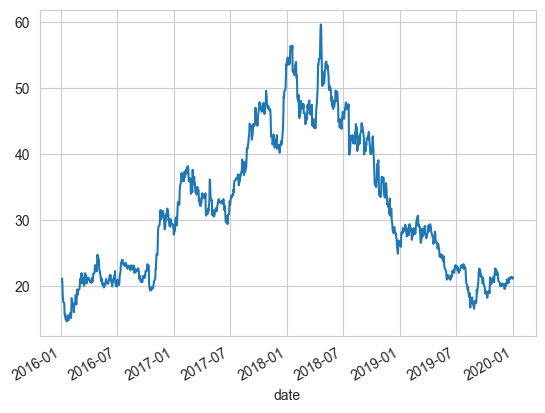

In [14]:
prices.iloc[:, 0].plot()

<Axes: xlabel='date'>

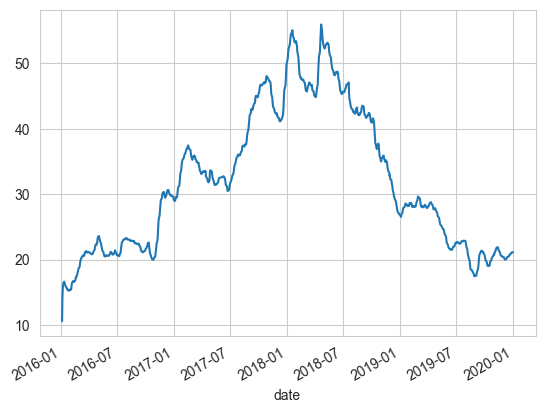

In [15]:
smoothed_prices.iloc[:, 0].plot()

### Compute rolling hedge ratio using Kalman Filter

### What is hedge ratio? 
you have two stocks that normally move together, for eg
- X = MSFT 
- Y = APPL
These two stocks move together but in differnt scales. 

Example: 
- MSFT: +1% 
- APPL: +1.5%
to hedge 1 dollar worth of MSFT, you would need 1.5 dollars of APPL so
1.5 is the hedge ratio

put simply 

spread = Y - BX, where B is the hedge ratio 


bascially we do a linear comb of the two and the residuals is a stable time series, we can trade this spread. 
this is diff to VECM because we want a new hedge ratio B at each time 

In [16]:
np.eye(2)

array([[1., 0.],
       [0., 1.]])

In [22]:
def KFHedgeRatio(x, y):
    """Estimate Hedge Ratio"""
    delta = 1e-3
    trans_cov = delta / (1 - delta) * np.eye(2) # very small transition covariance
    obs_mat = np.expand_dims(np.vstack([[x], [np.ones(len(x))]]).T, axis=1) # becomes (n, 1, 2) shape

    kf = KalmanFilter(n_dim_obs=1, n_dim_state=2, # y is 1 d, state is 2 d (hedge ratio and intercept)
                      initial_state_mean=[0, 0],
                      initial_state_covariance=np.ones((2, 2)),
                      transition_matrices=np.eye(2),  # identity matrix, best prediction for hedge ratio and intercept is previous value
                      observation_matrices=obs_mat,
                      observation_covariance=2,
                      transition_covariance=trans_cov) # kalman estiamtes the hedge ratio and intercept over time

    state_means, _ = kf.filter(y.values)
    return -state_means

### Estimate mean reversion half life

In [ ]:
def estimate_half_life(spread):
    X = spread.shift().iloc[1:].to_frame().assign(const=1) # each row has lagged spread and constant term
    # shift to avoid lookahead bias
    # assume spread follows delta_spread = beta * lagged_spread + epsilon, where beta < 0 for mean reverting series
    y = spread.diff().iloc[1:] # spread difference, meaning how much spread changed from previous period
    beta = (np.linalg.inv(X.T @ X) @ X.T @ y).iloc[0] 
    halflife = int(round(-np.log(2) / beta, 0)) # formula for half-life mean reversion How long until the spread closes half of the distance back to the mean?
    return max(halflife, 1)

### Compute Spread & Bollinger Bands

In [19]:
def get_spread(candidates, prices):
    pairs = []
    half_lives = []

    periods = pd.DatetimeIndex(sorted(candidates.test_end.unique()))
    start = time()
    for p, test_end in enumerate(periods, 1):
        start_iteration = time()

        period_candidates = candidates.loc[candidates.test_end == test_end, ['y', 'x']]
        trading_start = test_end + pd.DateOffset(days=1)
        t = trading_start - pd.DateOffset(years=2)
        T = trading_start + pd.DateOffset(months=6) - pd.DateOffset(days=1)
        max_window = len(prices.loc[t: test_end].index)
        print(test_end.date(), len(period_candidates))
        for i, (y, x) in enumerate(zip(period_candidates.y, period_candidates.x), 1):
            if i % 1000 == 0:
                msg = f'{i:5.0f} | {time() - start_iteration:7.1f} | {time() - start:10.1f}'
                print(msg)
            pair = prices.loc[t: T, [y, x]]
            pair['hedge_ratio'] = KFHedgeRatio(y=KFSmoother(prices.loc[t: T, y]),
                                               x=KFSmoother(prices.loc[t: T, x]))[:, 0]
        
            pair['spread'] = pair[y].add(pair[x].mul(pair.hedge_ratio)) # this spread is stationary, it represents the value of long y and short hedge_ratio * x
            half_life = estimate_half_life(pair.spread.loc[t: test_end])                

            spread = pair.spread.rolling(window=min(2 * half_life, max_window))
            pair['z_score'] = pair.spread.sub(spread.mean()).div(spread.std())
            pairs.append(pair.loc[trading_start: T].assign(s1=y, s2=x, period=p, pair=i).drop([x, y], axis=1))

            half_lives.append([test_end, y, x, half_life])
    return pairs, half_lives

In [20]:
candidates = pd.read_hdf('backtest.h5', 'candidates')
candidates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29399 entries, 6 to 22699
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   test_end  29399 non-null  datetime64[ns]
 1   w1        29399 non-null  float64       
 2   w2        29399 non-null  float64       
 3   joh_sig   29399 non-null  bool          
 4   eg        29399 non-null  float64       
 5   eg_sig    29399 non-null  bool          
 6   coint     29399 non-null  bool          
 7   y         29399 non-null  object        
 8   x         29399 non-null  object        
dtypes: bool(3), datetime64[ns](1), float64(3), object(2)
memory usage: 1.7+ MB


In [21]:
candidates

,test_end,w1,w2,joh_sig,eg,eg_sig,coint,y,x
6,2016-12-31,0.112295,0.052680,True,0.744821,False,False,SPY.US,C.US
12,2016-12-31,0.142082,-0.325900,False,0.044346,True,False,SPY.US,NVDA.US
15,2016-12-31,0.308580,-1.448434,True,0.015434,True,True,CSCO.US,SPY.US
21,2016-12-31,0.117961,0.007331,True,0.639055,False,False,SPY.US,GS.US
35,2016-12-31,0.221539,-0.529602,True,0.012558,True,True,SPY.US,AMD.US
...,...,...,...,...,...,...,...,...,...
22630,2019-06-30,0.724119,0.022012,True,0.242477,False,False,VNM.US,REGN.US
22664,2019-06-30,0.730042,0.106124,True,0.036398,True,True,EXPE.US,VNM.US
22681,2019-06-30,0.819393,-0.548634,True,0.032795,True,True,TFC.US,VNM.US
22695,2019-06-30,1.162844,-0.904759,True,0.027240,True,True,FITB.US,VNM.US


In [71]:
pairs, half_lives = get_spread(candidates, smoothed_prices)

2016-12-31 3793
 1000 |   180.5 |      180.5
 2000 |   360.7 |      360.7
 3000 |   536.6 |      536.6
2017-03-31 2118
 1000 |   206.2 |      883.1
 2000 |   415.7 |     1092.6
2017-06-30 4311
 1000 |   244.6 |     1363.1
 2000 |   486.8 |     1605.3
 3000 |   750.6 |     1869.1
 4000 |   989.5 |     2108.0
2017-09-30 2379
 1000 |   271.5 |     2481.2
 2000 |   538.0 |     2747.7
2017-12-31 3260
 1000 |   706.0 |     3554.9
 2000 |  2552.6 |     5401.5
 3000 |  2927.6 |     5776.4
2018-03-31 3819
 1000 |   354.2 |     6228.5
 2000 |   652.1 |     6526.5
 3000 |   954.5 |     6828.9
2018-06-30 2742
 1000 |   299.7 |     7372.7
 2000 |   595.4 |     7668.4
2018-09-30 3010
 1000 |   292.7 |     8182.6
 2000 |   588.5 |     8478.3
 3000 |   883.9 |     8773.7
2018-12-31 2903
 1000 |   292.5 |     9069.4
 2000 |   582.5 |     9359.4
2019-03-31 2647
 1000 |   295.1 |     9920.7
 2000 |   588.3 |    10213.9
2019-06-30 2679
 1000 |   290.2 |    10693.5
 2000 |   585.2 |    10988.6


### Collect Results

#### Half Lives

In [72]:
hl = pd.DataFrame(half_lives, columns=['test_end', 's1', 's2', 'half_life'])
hl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33661 entries, 0 to 33660
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   test_end   33661 non-null  datetime64[ns]
 1   s1         33661 non-null  object        
 2   s2         33661 non-null  object        
 3   half_life  33661 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 1.0+ MB


In [73]:
hl.half_life.describe()

count    33661.000000
mean        25.199519
std         10.223437
min          1.000000
25%         20.000000
50%         24.000000
75%         28.000000
max       1057.000000
Name: half_life, dtype: float64

In [74]:
hl.to_hdf('backtest.h5', 'half_lives')

#### Pair Data

In [75]:
pair_data = pd.concat(pairs)
pair_data.info(null_counts=True)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4229473 entries, 2017-01-03 to 2019-12-31
Data columns (total 7 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   hedge_ratio  4229473 non-null  float64
 1   spread       4229473 non-null  float64
 2   z_score      4229473 non-null  float64
 3   s1           4229473 non-null  object 
 4   s2           4229473 non-null  object 
 5   period       4229473 non-null  int64  
 6   pair         4229473 non-null  int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 258.1+ MB


In [76]:
pair_data.to_hdf('backtest.h5', 'pair_data')

In [77]:
pair_data = pd.read_hdf('backtest.h5', 'pair_data')

### Identify Long & Short Entry and Exit Dates

In [78]:
def get_trades(data):
    pair_trades = []
    for i, ((period, s1, s2), pair) in enumerate(data.groupby(['period', 's1', 's2']), 1):
        if i % 100 == 0:
            print(i)

        first3m = pair.first('3M').index
        last3m = pair.last('3M').index

        entry = pair.z_score.abs() > 2
        entry = ((entry.shift() != entry)
                 .mul(np.sign(pair.z_score))
                 .fillna(0)
                 .astype(int)
                 .sub(2))

        exit = (np.sign(pair.z_score.shift().fillna(method='bfill'))
                != np.sign(pair.z_score)).astype(int) - 1

        trades = (entry[entry != -2].append(exit[exit == 0])
                  .to_frame('side')
                  .sort_values(['date', 'side'])
                  .squeeze())
        if not isinstance(trades, pd.Series):
            continue
        try:
            trades.loc[trades < 0] += 2
        except:
            print(type(trades))
            print(trades)
            print(pair.z_score.describe())
            break

        trades = trades[trades.abs().shift() != trades.abs()]
        window = trades.loc[first3m.min():first3m.max()]
        extra = trades.loc[last3m.min():last3m.max()]
        n = len(trades)

        if window.iloc[0] == 0:
            if n > 1:
                print('shift')
                window = window.iloc[1:]
        if window.iloc[-1] != 0:
            extra_exits = extra[extra == 0].head(1)
            if extra_exits.empty:
                continue
            else:
                window = window.append(extra_exits)

        trades = pair[['s1', 's2', 'hedge_ratio', 'period', 'pair']].join(window.to_frame('side'), how='right')
        trades.loc[trades.side == 0, 'hedge_ratio'] = np.nan
        trades.hedge_ratio = trades.hedge_ratio.ffill()
        pair_trades.append(trades)
    return pair_trades

In [79]:
pair_trades = get_trades(pair_data)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
1850

In [80]:
pair_trade_data = pd.concat(pair_trades)
pair_trade_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 134450 entries, 2017-01-03 to 2019-10-04
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   s1           134450 non-null  object 
 1   s2           134450 non-null  object 
 2   hedge_ratio  134450 non-null  float64
 3   period       134450 non-null  int64  
 4   pair         134450 non-null  int64  
 5   side         134450 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 7.2+ MB


In [81]:
pair_trade_data.head()

,s1,s2,hedge_ratio,period,pair,side
date,,,,,,
2017-01-03,AA.US,ACWI.US,-0.533861,1,16,-1
2017-01-12,AA.US,ACWI.US,-0.533861,1,16,0
2017-01-03,AA.US,ACWX.US,-0.799916,1,54,-1
2017-01-12,AA.US,ACWX.US,-0.799916,1,54,0
2017-01-03,AA.US,DEM.US,-0.896395,1,376,-1


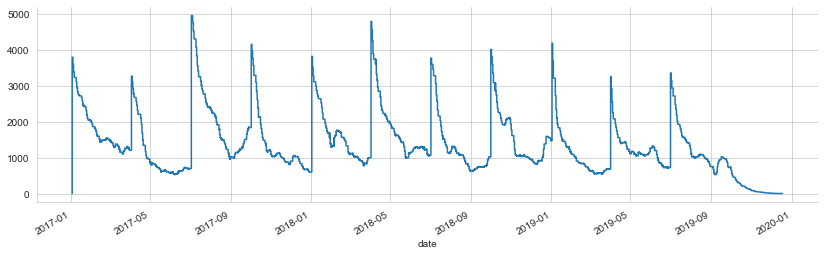

In [84]:
trades = pair_trade_data['side'].copy()
trades.loc[trades != 0] = 1
trades.loc[trades == 0] = -1
trades.sort_index().cumsum().plot(figsize=(14, 4))
sns.despine()

In [83]:
pair_trade_data.to_hdf('backtest.h5', 'pair_trades')